In [5]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)


In [6]:
df = pd.read_csv("food_social_media_data_enhanced.csv")

# First look
print(df.head())
print(df.shape)


    Post_ID Brand_Name     Post_Type  Food_Category        Post_DateTime  \
0  POST_001   TacoBell  Static Image  Healthy/Vegan  2025-12-28 13:08:44   
1  POST_002   TacoBell         Story  Healthy/Vegan  2025-02-02 19:55:23   
2  POST_003  Starbucks  Static Image  Healthy/Vegan  2025-04-28 16:45:01   
3  POST_004   TacoBell      Carousel    Street Food  2025-05-30 07:11:44   
4  POST_005        KFC  Reel (Video)      Fast Food  2025-09-02 01:30:59   

   Total_Likes  Total_Shares  Total_Comments  Reaction_Love  Reaction_Yummy  \
0         3429           667             333           1299             544   
1         3775           391              94           1973            1076   
2         3190           164             271           1187             791   
3           95            18               2             52              27   
4         5859           612             495           1976            1627   

   ...  Sentiment_Score  Virality_Score Virality_Category Device_Typ

In [3]:
print(df.info())
print(df.describe())
print(df.describe(include='object'))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Post_ID               500 non-null    object 
 1   Brand_Name            500 non-null    object 
 2   Post_Type             500 non-null    object 
 3   Food_Category         500 non-null    object 
 4   Post_DateTime         500 non-null    object 
 5   Total_Likes           500 non-null    int64  
 6   Total_Shares          500 non-null    int64  
 7   Total_Comments        500 non-null    int64  
 8   Reaction_Love         500 non-null    int64  
 9   Reaction_Yummy        500 non-null    int64  
 10  Reaction_Dislike      500 non-null    int64  
 11  Post_Hour             500 non-null    int64  
 12  Post_Day              500 non-null    object 
 13  Gender                500 non-null    object 
 14  Age_Group             500 non-null    object 
 15  Region                5

Post_ID                 0
Brand_Name              0
Post_Type               0
Food_Category           0
Post_DateTime           0
Total_Likes             0
Total_Shares            0
Total_Comments          0
Reaction_Love           0
Reaction_Yummy          0
Reaction_Dislike        0
Post_Hour               0
Post_Day                0
Gender                  0
Age_Group               0
Region                  0
City_Tier               0
Total_Engagement        0
Engagement_Rate         0
Engagement_Category     0
Month                   0
Month_Number            0
Quarter                 0
Year                    0
Is_Weekend              0
Day_Type                0
Is_Peak_Hour            0
Time_Period             0
Positive_Reactions      0
Sentiment_Score         0
Virality_Score          0
Virality_Category       0
Device_Type             0
Campaign_Type           0
Content_Theme           0
Share_Rate              0
Comment_Rate            0
Performance_Score       0
Performance_

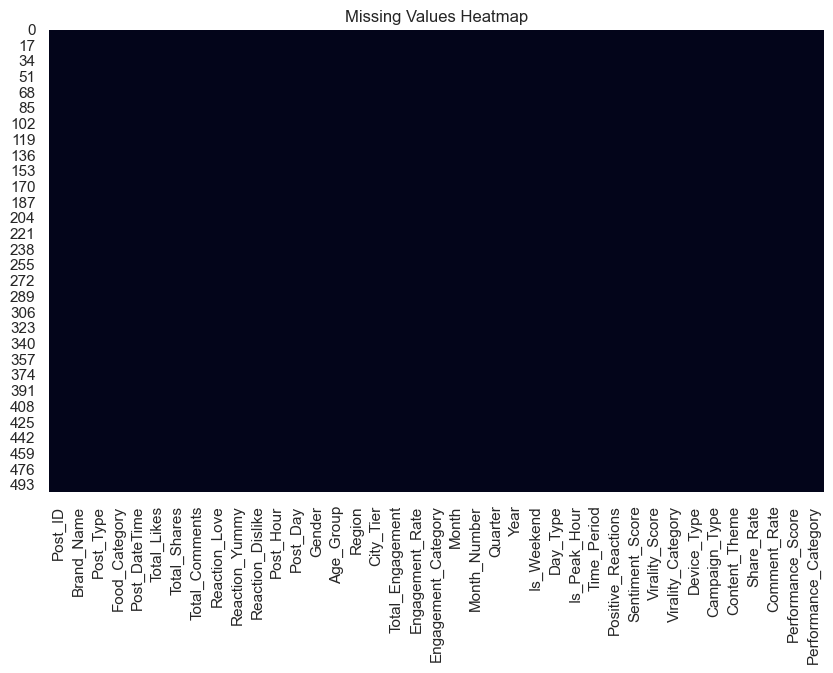

In [4]:
missing = df.isnull().sum()
print(missing)

# Visualize missing values
plt.figure()
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()


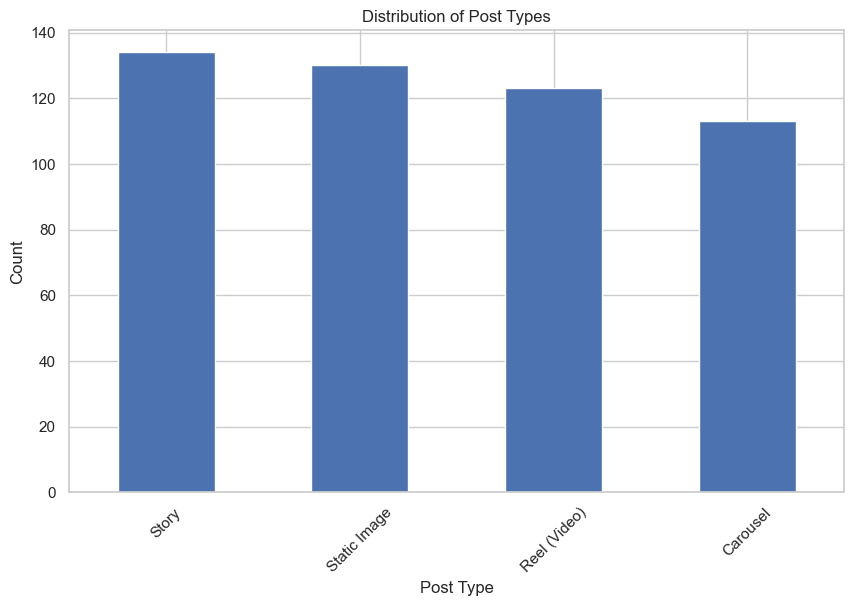

In [14]:
plt.figure()
df['Post_Type'].value_counts().plot(kind='bar')
plt.title("Distribution of Post Types")
plt.xlabel("Post Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


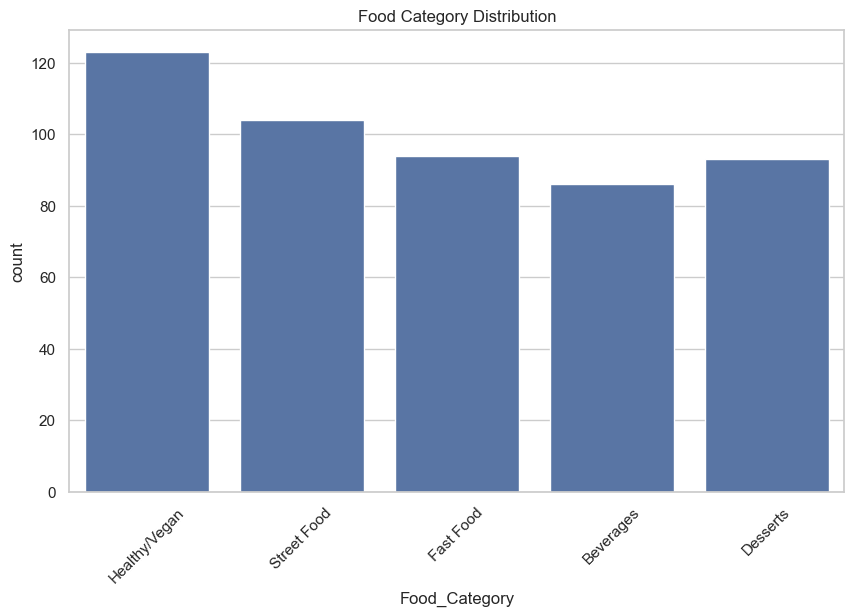

In [15]:
plt.figure()
sns.countplot(x='Food_Category', data=df)
plt.xticks(rotation=45)
plt.title("Food Category Distribution")
plt.show()



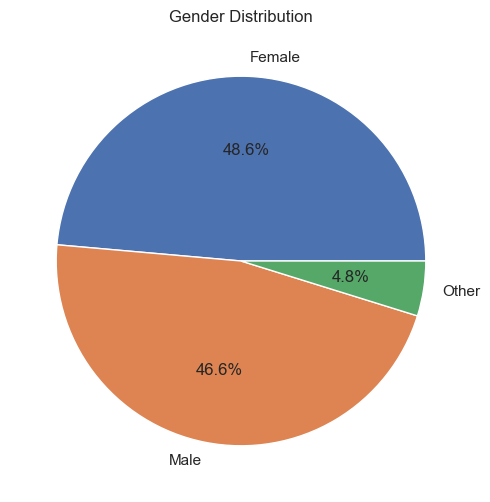

In [16]:
gender_counts = df['Gender'].value_counts()

plt.figure()
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%')
plt.title("Gender Distribution")
plt.show()



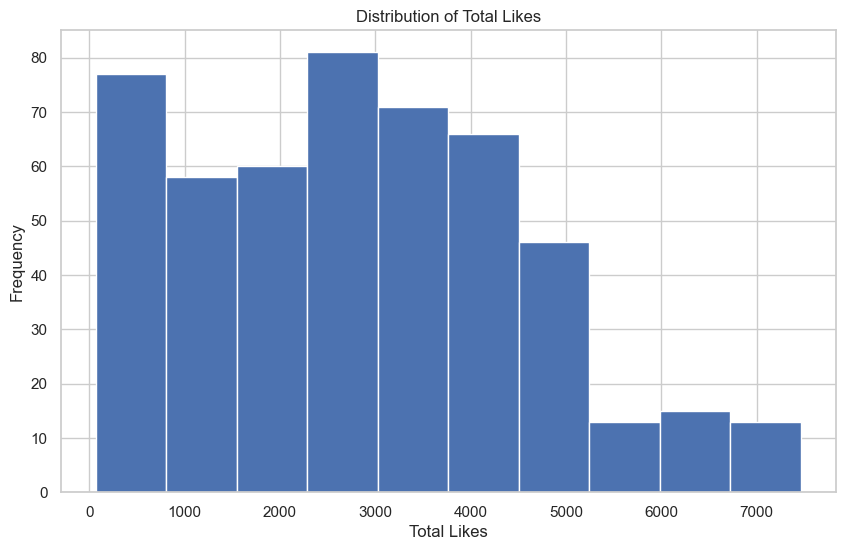

In [17]:
plt.figure()
plt.hist(df['Total_Likes'], bins=10)
plt.title("Distribution of Total Likes")
plt.xlabel("Total Likes")
plt.ylabel("Frequency")
plt.show()



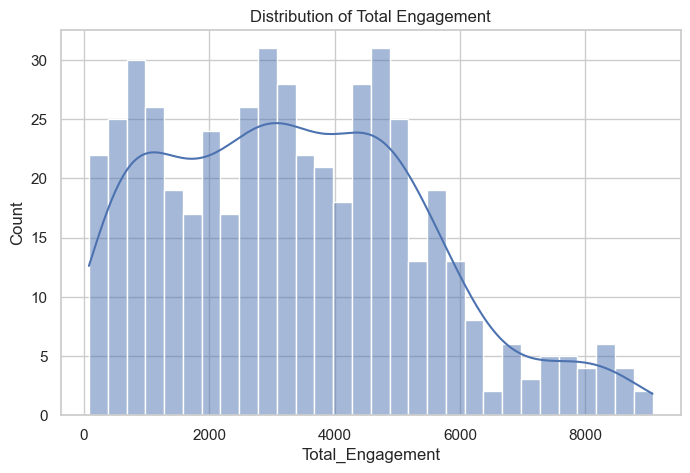

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df['Total_Engagement'], bins=30, kde=True)
plt.title("Distribution of Total Engagement")
plt.show()

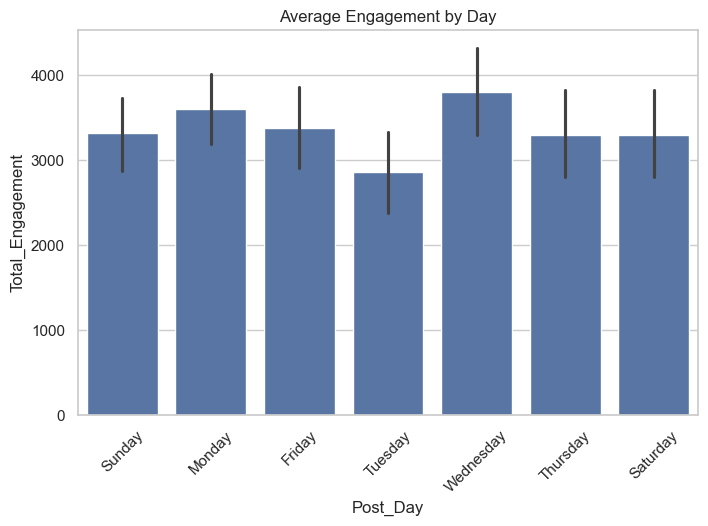

In [9]:
plt.figure(figsize=(8,5))
sns.barplot(x='Post_Day', y='Total_Engagement', data=df, estimator=np.mean)
plt.title("Average Engagement by Day")
plt.xticks(rotation=45)
plt.show()

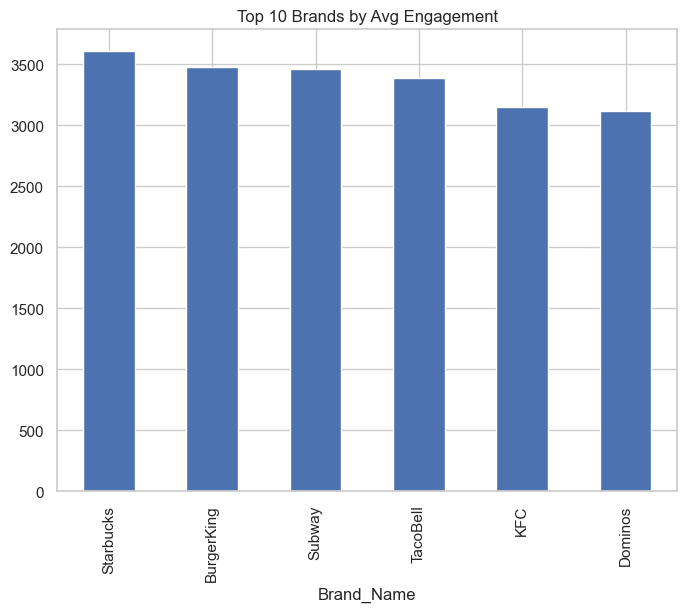

In [10]:
top_brands = df.groupby('Brand_Name')['Total_Engagement'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,6))
top_brands.head(10).plot(kind='bar')
plt.title("Top 10 Brands by Avg Engagement")
plt.show()

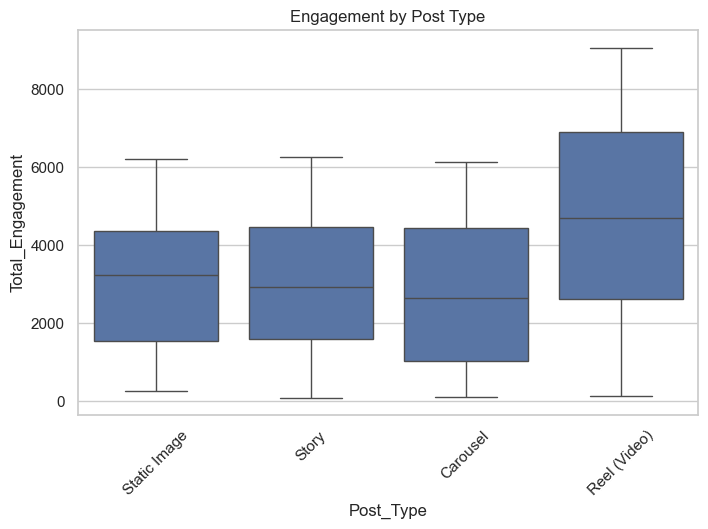

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Post_Type', y='Total_Engagement', data=df)
plt.title("Engagement by Post Type")
plt.xticks(rotation=45)
plt.show()

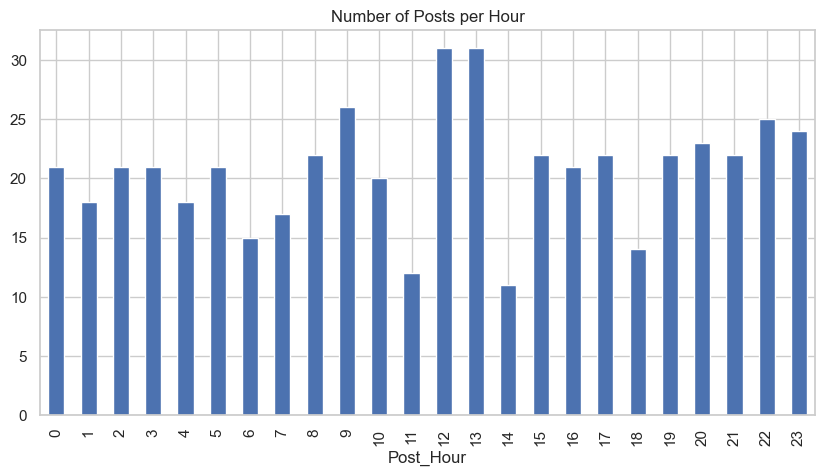

In [13]:
hour_counts = df['Post_Hour'].value_counts().sort_index()

plt.figure(figsize=(10,5))
hour_counts.plot(kind='bar')
plt.title("Number of Posts per Hour")
plt.show()

In [14]:
hour_analysis = df.groupby('Post_Hour').agg({
    'Total_Engagement': ['mean','median','count']
})

print(hour_analysis)

          Total_Engagement              
                      mean  median count
Post_Hour                               
0              4345.666667  4348.0    21
1              4621.388889  4505.0    18
2              3590.714286  3355.0    21
3              3230.761905  3166.0    21
4              2705.500000  2711.0    18
5              3107.333333  3589.0    21
6              3477.066667  2912.0    15
7              2794.823529  2080.0    17
8              2857.272727  2857.5    22
9              3565.038462  3333.5    26
10             2739.950000  2611.5    20
11             3317.500000  3456.0    12
12             4077.258065  3629.0    31
13             3446.161290  3900.0    31
14             3252.454545  3215.0    11
15             2783.363636  3099.5    22
16             4087.476190  3671.0    21
17             2748.318182  2732.5    22
18             3706.000000  4163.5    14
19             2793.772727  2568.0    22
20             3614.000000  3274.0    23
21             2